In [25]:
# House Price Prediction - Bengaluru Housing Data
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [26]:
# Load the data
df = pd.read_csv('Bengaluru_House_Data.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [27]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [28]:
# Check for missing values
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [29]:
# Handle missing values
# Fill missing society values with 'Unknown'
df['society'] = df['society'].fillna('Unknown')

# Drop rows with missing target variable (price)
df = df.dropna(subset=['price'])

# Fill bath and balcony with median values
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (13320, 9)


In [30]:
# Feature Engineering: Extract BHK from size column
def extract_bhk(size):
    if pd.isna(size):
        return 1
    if 'BHK' in size:
        return int(size.split(' ')[0])
    elif 'Bedroom' in size:
        return int(size.split(' ')[0])
    elif 'RK' in size:
        return 1
    else:
        return 1

df['bhk'] = df['size'].apply(extract_bhk)

In [31]:
# Handle total_sqft column (some values are ranges)
def parse_sqft(sqft):
    if pd.isna(sqft):
        return np.nan
    if isinstance(sqft, (int, float)):
        return float(sqft)
    if 'Sq. Meter' in str(sqft):
        return float(str(sqft).split('Sq. Meter')[0].strip())
    if 'Sq. Yards' in str(sqft):
        return float(str(sqft).split('Sq. Yards')[0].strip())
    if 'Acres' in str(sqft):
        return float(str(sqft).split('Acres')[0].strip()) * 43560
    if '-' in str(sqft):
        parts = str(sqft).split('-')
        return (float(parts[0].strip()) + float(parts[1].strip())) / 2
    try:
        return float(sqft)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(parse_sqft)
df = df.dropna(subset=['total_sqft'])

In [32]:
# Add price per sqft feature
df['price_per_sqft'] = df['price'] * 1000000 / df['total_sqft']  # Price in lakhs per sqft

# Remove outliers (price_per_sqft beyond 3 standard deviations)
mean_pps = df['price_per_sqft'].mean()
std_pps = df['price_per_sqft'].std()
df = df[(df['price_per_sqft'] > mean_pps - 3*std_pps) & (df['price_per_sqft'] < mean_pps + 3*std_pps)]

In [33]:
# Check availability column
df['availability'].value_counts()

availability
Ready To Move    10571
18-Dec             306
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

In [34]:
# Create a feature for "Ready To Move"
df['is_ready_to_move'] = df['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)

In [35]:
# Location - keep only top locations (frequency > 20)
location_counts = df['location'].value_counts()
top_locations = location_counts[location_counts > 20].index
df['location'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

In [36]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ['area_type', 'location', 'society']

for col in categorical_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [37]:
# Select features for modeling
features = ['bhk', 'total_sqft', 'bath', 'balcony', 'is_ready_to_move', 
            'area_type_encoded', 'location_encoded', 'society_encoded']
target = 'price'

X = df[features]
y = df[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (13308, 8)
Target shape: (13308,)


In [38]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'model': model
    }
    
    print(f"\n{name}:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")


Linear Regression:
MAE: 58.16
RMSE: 149.91
R2 Score: 0.1555

Ridge:
MAE: 58.16
RMSE: 149.91
R2 Score: 0.1555

Lasso:
MAE: 58.16
RMSE: 149.90
R2 Score: 0.1555

Random Forest:
MAE: 35.04
RMSE: 110.25
R2 Score: 0.5432

Gradient Boosting:
MAE: 37.98
RMSE: 110.03
R2 Score: 0.5450


In [40]:
# Compare models
results_df = pd.DataFrame(results).T
results_df[['MAE', 'RMSE', 'R2']].sort_values('R2', ascending=False)

,MAE,RMSE,R2
Gradient Boosting,37.976904,110.03421,0.544991
Random Forest,35.037363,110.254819,0.543165
Lasso,58.15856,149.903432,0.155523
Linear Regression,58.161879,149.907617,0.155476
Ridge,58.161334,149.908084,0.155471


In [41]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R2 score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best R2 score: 0.575127893488857


In [42]:
# Evaluate best model
y_pred_best = best_rf.predict(X_test_scaled)
print(f"Best Random Forest R2 Score: {r2_score(y_test, y_pred_best):.4f}")

Best Random Forest R2 Score: 0.5506


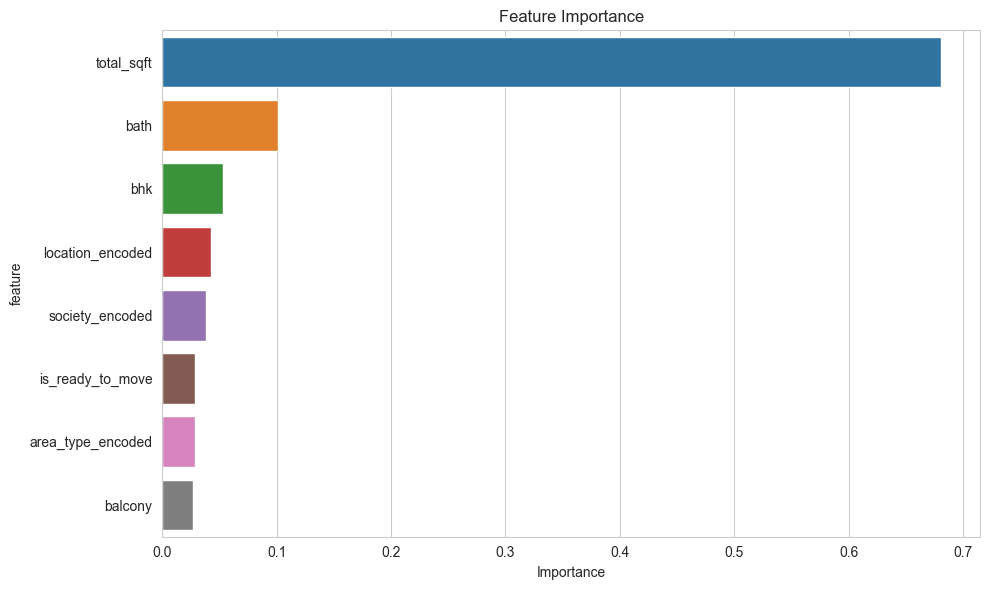

In [43]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [44]:
# Save the model and preprocessing objects
import joblib

# Save best model
joblib.dump(best_rf, 'house_price_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

# Save feature names
joblib.dump(features, 'feature_names.pkl')

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!
